# 04 — Top 10 Most Profitable Products
Highest-profit products ranked with margin percentage, colored by category.


In [1]:
from pyhive import hive
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PALETTE = sns.color_palette("muted")

def get_conn():
    return hive.connect(host="hive-server2", port=10000,
                        database="default", auth="NONE")

def fetch_df(cur, sql):
    cur.execute(sql)
    cols = [d[0].split(".")[-1] for d in cur.description]
    return pd.DataFrame(cur.fetchall(), columns=cols)

def fmt_usd(v):
    if abs(v) >= 1_000_000:
        return f"${v/1_000_000:.2f}M"
    if abs(v) >= 1_000:
        return f"${v/1_000:.1f}K"
    return f"${v:.0f}"

conn = get_conn()
cur  = conn.cursor()
print("Connected.")


Connected.


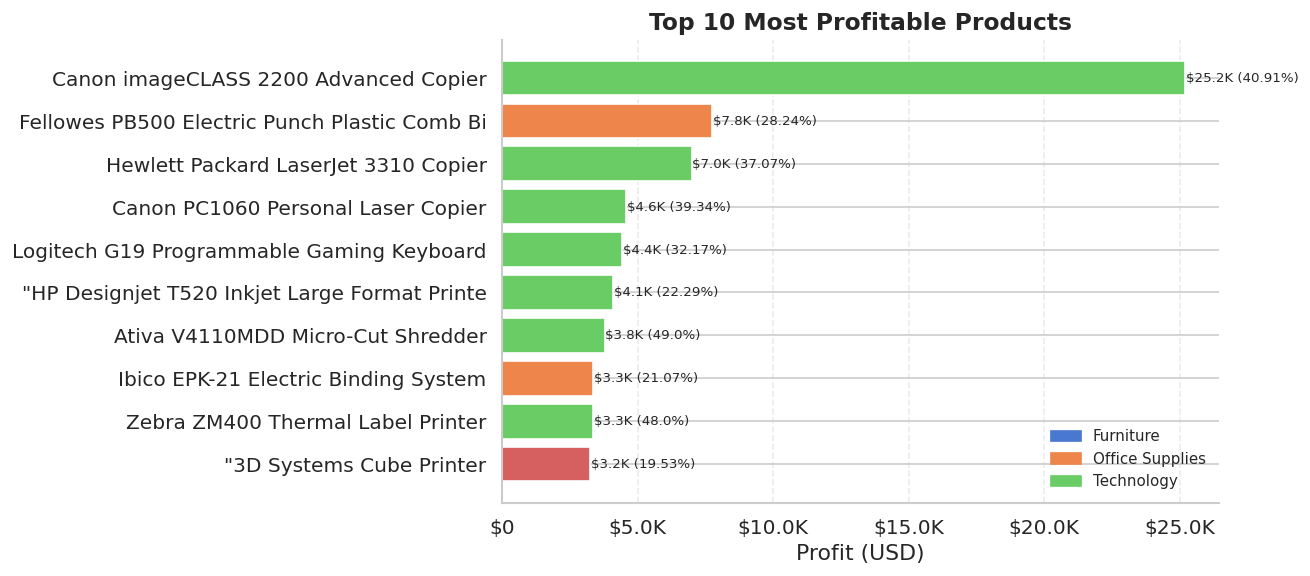

In [2]:
# ── Top 10 Most Profitable Products ──────────────────────────────────────────
top_prod = fetch_df(cur, """
    SELECT p.product_name,
           p.category,
           ROUND(SUM(oi.profit), 2)                      AS profit,
           ROUND(SUM(oi.profit)/SUM(oi.sales)*100, 2)   AS margin_pct
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    GROUP BY p.product_name, p.category
    ORDER BY profit DESC
    LIMIT 10
""")

cat_pal = {"Furniture": PALETTE[0], "Office Supplies": PALETTE[1],
           "Technology": PALETTE[2]}
colors  = [cat_pal.get(c, PALETTE[3]) for c in top_prod["category"][::-1]]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(top_prod["product_name"].str[:45][::-1],
               top_prod["profit"][::-1],
               color=colors, edgecolor="white")
for bar, margin in zip(bars, top_prod["margin_pct"][::-1]):
    ax.text(bar.get_width() + 30,
            bar.get_y() + bar.get_height()/2,
            f"{fmt_usd(bar.get_width())} ({margin}%)",
            va="center", fontsize=8)

handles = [mpatches.Patch(color=v, label=k) for k, v in cat_pal.items()]
ax.legend(handles=handles, frameon=False, fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: fmt_usd(v)))
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_xlabel("Profit (USD)")
ax.set_title("Top 10 Most Profitable Products")
plt.tight_layout()
plt.show()


In [3]:
cur.close()
conn.close()
print("Done.")


Done.
